# Chapter 6

## 6.1 get physical info from circ.

* state vec

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

circ = QuantumCircuit(1)

# initialize
initial_vector = [1/np.sqrt(2), 1j*np.sqrt(2)] 
circ.initialize(initial_vector, [0], normalize=True)

# 使用 Statevector 直接计算电路的状态向量
state = Statevector(circ)
print("\n状态向量：")
print(state.data)


状态向量：
[0.4472136+0.j         0.       +0.89442719j]


* get operator matrix

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import numpy as np

# initialize
circ = QuantumCircuit(1)
circ.rx(np.pi/2, 0)

# 使用 Operator 直接计算电路的幺正矩阵(不接受initialize函数, 此过程非幺正操作。)
unitary = Operator(circ)
print("幺正矩阵：")
print(unitary.data)

幺正矩阵：
[[0.70710678+0.j         0.        -0.70710678j]
 [0.        -0.70710678j 0.70710678+0.j        ]]


* visualization(看 Chapter7, 放弃旧版。)

**显然bloch_vec，unitary在测量前，Qsphere和histogram要在测量后（因为其结果是包括测量的）。**

## 6.2 real comp 

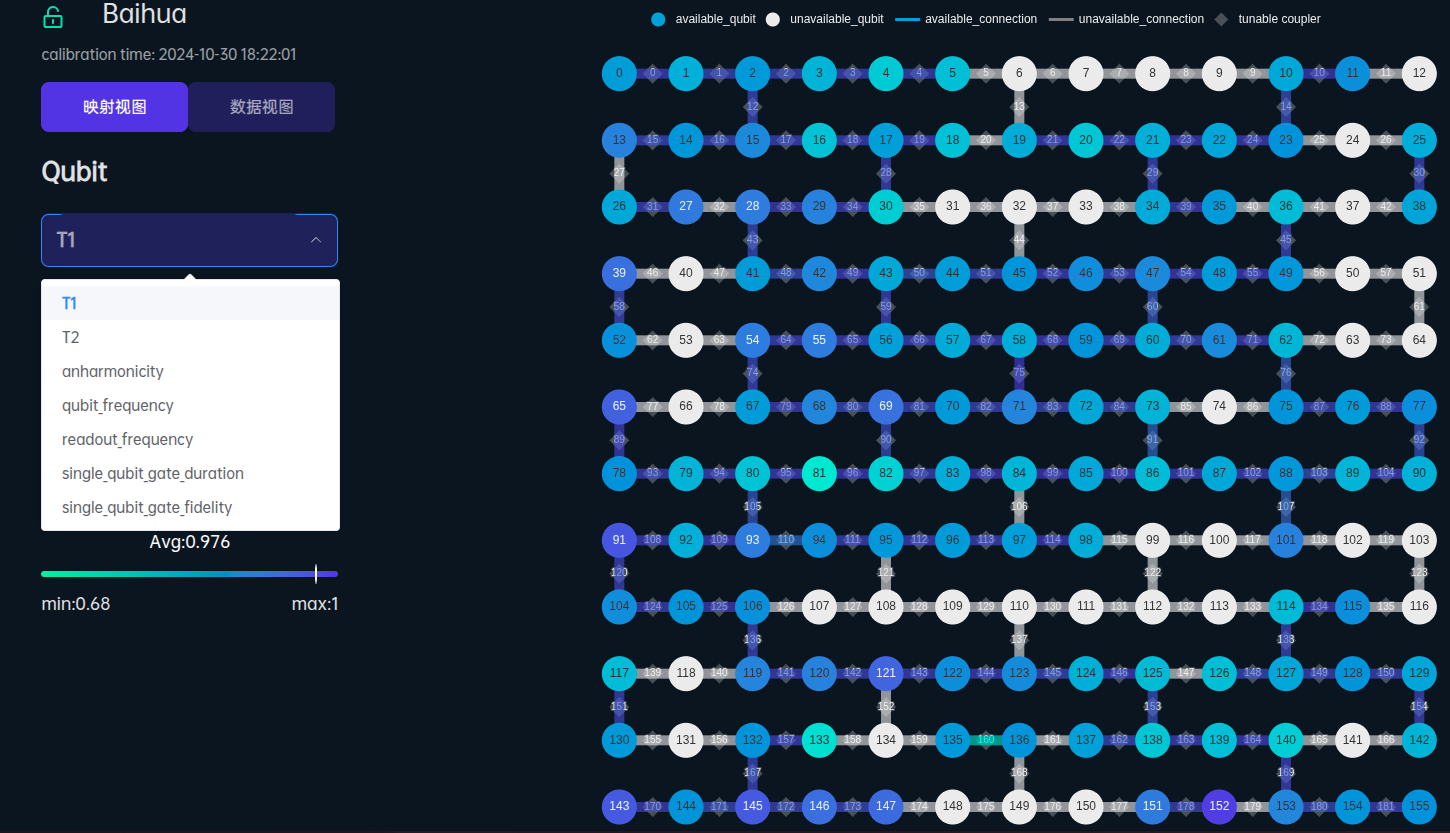

以百度的超导电路平台为例。圆为单量子比特，菱形连接处为双量子比特（这个平台只有Cz）。
**转译受基础门影响，但不一定都是基础门。**

* T1: 纵向弛豫时间，反映量子态**自发**从激发态回到基态的平均时间。
* T2: 横向弛豫时间（相位相干时间）。
* qubit_frequency: 量子比特工作频率, 影响门操作速度和串扰。
* readout_frequency: 读出频率。
* single_qubit_gate_duration：单量子比特门持续时间
* single_qubit_gate_fidelity: 保真度。

In [ ]:
# try to specified certain quatum bits.

from quark import Task
import os
from qiskit import qasm2
import time
import matplotlib.pyplot as plt

def quark_comp(qiskit_circ, repeat_count=1, my_job='my_job', chip='Baihua', target_qubits=[]):
    # circ trans
    qasm_circ = qasm2.dumps(qiskit_circ)
    # tmgr
    token = os.getenv('QUARK_API_TOKEN')
    tmgr = Task(token) # task manager
    task = {
    'chip': chip,  
    'name': my_job,  
    'circuit':qasm_circ, # circuit written in OpenQASM2.0
    'compile': True, # 可能用模拟机。(你要是自信自己写的全是基础门就用False.)
    'options':{
        'correct': False,
        'target_qubits': target_qubits # 具体bit而非范围。 
    }
    }

    tid = tmgr.run(task, repeat=repeat_count) # shots = repeat*1024
    res = tmgr.result(tid)
    while not res:
        time.sleep(1)
        res = tmgr.result(tid)
    display(res)

    data = res['count']
    bases = sorted(data)
    count = [data[base] for base in bases]
    plt.bar(bases, count)
    plt.xticks(rotation=45)

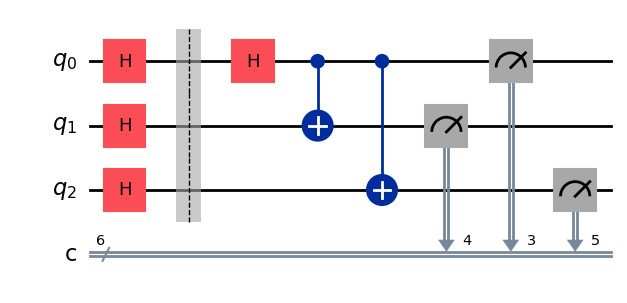

In [ ]:
# case:
from qiskit import QuantumCircuit
from qiskit import qasm2
import numpy as np

circ = QuantumCircuit(3, 6) # 多次测量备用。
circ.h([0, 1, 2])
circ.barrier([0, 1, 2]) # barrier and reset.
circ.h([0])
circ.cx(0, 1)
circ.cx(0, 2)
circ.measure([0, 1, 2], [3, 4, 5])
display(circ.draw('mpl'))

{'count': {'100': 299,
  '000': 224,
  '010': 192,
  '110': 293,
  '011': 3,
  '101': 9,
  '001': 2,
  '111': 2},
 'corrected': {},
 'chip': 'Baihua',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[6];\nh q[0];\nh q[1];\nh q[2];\nbarrier q[0],q[1],q[2];\nh q[0];\ncx q[0],q[1];\ncx q[0],q[2];\nmeasure q[0] -> c[3];\nmeasure q[1] -> c[4];\nmeasure q[2] -> c[5];',
 'transpiled': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[73];\ncreg c[6];\nh q[70];\nh q[71];\nh q[72];\nbarrier q[71],q[70],q[72];\nh q[71];\ncx q[71],q[70];\ncx q[71],q[72];\nbarrier q[71],q[70],q[72];\nmeasure q[71] -> c[3];\nmeasure q[70] -> c[4];\nmeasure q[72] -> c[5];',
 'qlisp': "[(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q70'),\n(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q71'),\n(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q72'),\n('Barrier', ('Q71', 'Q70', 'Q72')),\n(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q71'),\n(('U', 1.5707963267948966, 0.0, 3.1415

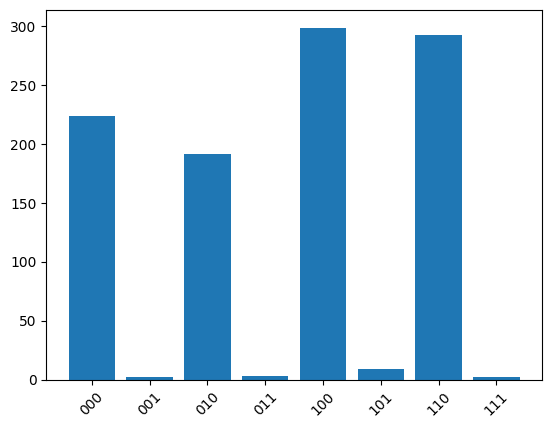

In [ ]:
quark_comp(circ, target_qubits=[70, 71, 72])